# 04 — Modelado: Prophet

## Objetivo
Construir un modelo de forecasting usando Prophet, desarrollado por Meta,
y comparar su performance contra SARIMA.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

# Carga de datos
train = pd.read_csv('../data/processed/train_features.csv')
train['date'] = pd.to_datetime(train['date'])
holidays = pd.read_csv('../data/raw/holidays_events.csv')
holidays['date'] = pd.to_datetime(holidays['date'])

# Filtrar GROCERY I - Tienda 1
serie = train[(train['store_nbr'] == 1) & 
              (train['family'] == 'GROCERY I')][['date', 'sales']].copy()

# Prophet requiere columnas con nombres específicos: ds y y
serie = serie.rename(columns={'date': 'ds', 'sales': 'y'})

print(f"Shape: {serie.shape}")
print(serie.head())

Importing plotly failed. Interactive plots will not work.


Shape: (1684, 2)
              ds       y
20208 2013-01-01     0.0
20209 2013-01-02  2652.0
20210 2013-01-03  2121.0
20211 2013-01-04  2056.0
20212 2013-01-05  2216.0


## 1. Preparación de Feriados

In [2]:
# Preparar feriados nacionales en formato Prophet
feriados_prophet = holidays[holidays['locale'] == 'National'][['date', 'description']].copy()
feriados_prophet = feriados_prophet.rename(columns={'date': 'ds', 'description': 'holiday'})
feriados_prophet = feriados_prophet.drop_duplicates()

print(f"Feriados nacionales: {len(feriados_prophet)}")
print(feriados_prophet.head())

Feriados nacionales: 174
           ds                              holiday
14 2012-08-10        Primer Grito de Independencia
19 2012-10-09           Independencia de Guayaquil
20 2012-10-12  Traslado Independencia de Guayaquil
21 2012-11-02                      Dia de Difuntos
22 2012-11-03              Independencia de Cuenca


## 2. División Train / Test

In [3]:
# División temporal — últimos 30 días para test
fecha_corte = serie['ds'].max() - pd.Timedelta(days=30)

train_serie = serie[serie['ds'] <= fecha_corte]
test_serie = serie[serie['ds'] > fecha_corte]

print(f"Train: {train_serie['ds'].min()} → {train_serie['ds'].max()} ({len(train_serie)} días)")
print(f"Test:  {test_serie['ds'].min()} → {test_serie['ds'].max()} ({len(test_serie)} días)")

Train: 2013-01-01 00:00:00 → 2017-07-16 00:00:00 (1654 días)
Test:  2017-07-17 00:00:00 → 2017-08-15 00:00:00 (30 días)


## 3. Entrenamiento del Modelo Prophet

In [4]:
# Entrenamiento Prophet
modelo_prophet = Prophet(
    seasonality_mode='multiplicative',  # estacionalidad multiplicativa
    yearly_seasonality=True,            # captura estacionalidad anual
    weekly_seasonality=True,            # captura estacionalidad semanal
    daily_seasonality=False,            # no aplica para datos diarios agregados
    holidays=feriados_prophet           # incorpora feriados nacionales
)

modelo_prophet.fit(train_serie)


23:05:54 - cmdstanpy - INFO - Chain [1] start processing
23:05:55 - cmdstanpy - INFO - Chain [1] done processing


## 4. Predicción y Evaluación

=== MÉTRICAS PROPHET ===
MAE:  298.34
RMSE: 377.47
MAPE: 13.15%


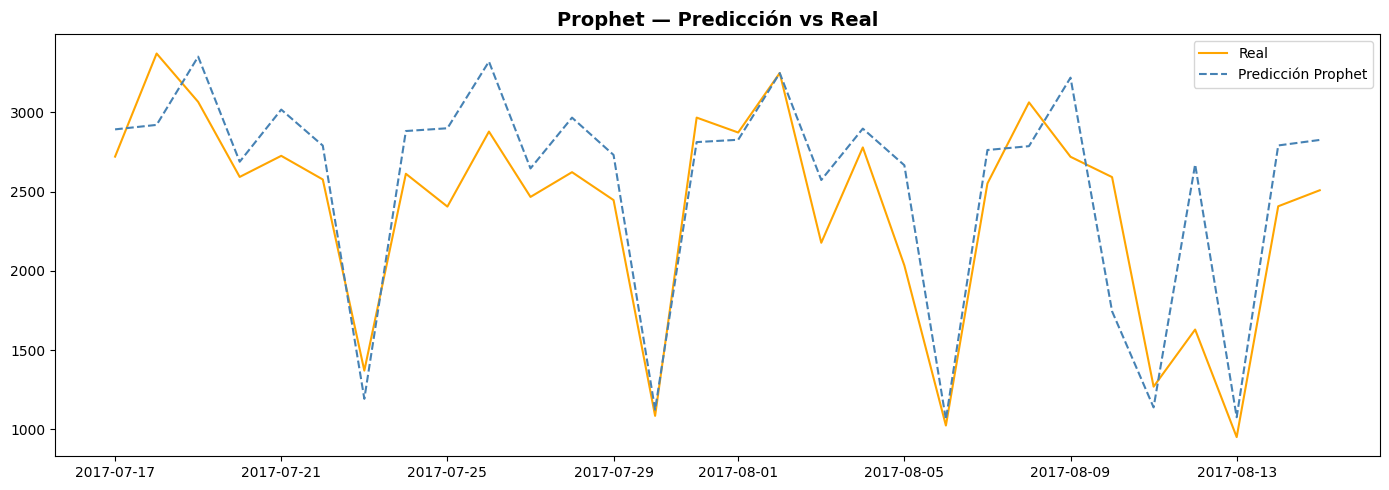

In [5]:
# Crear dataframe con fechas futuras para predecir
futuro = modelo_prophet.make_future_dataframe(periods=30, freq='D')

# Predicción
forecast = modelo_prophet.predict(futuro)

# Extraer solo el período de test
predicciones_prophet = forecast[forecast['ds'] > fecha_corte][['ds', 'yhat']].copy()
predicciones_prophet = predicciones_prophet.set_index('ds')['yhat']

# Métricas
def calcular_metricas(real, predicho):
    mae = np.mean(np.abs(real - predicho))
    rmse = np.sqrt(np.mean((real - predicho) ** 2))
    mask = real != 0
    mape = np.mean(np.abs((real[mask] - predicho[mask]) / real[mask])) * 100
    return mae, rmse, mape

real = test_serie.set_index('ds')['y']
mae, rmse, mape = calcular_metricas(real.values, predicciones_prophet.values)

print("=== MÉTRICAS PROPHET ===")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

# Visualización
plt.figure(figsize=(14, 5))
plt.plot(real.index, real.values, color='orange', linewidth=1.5, label='Real')
plt.plot(predicciones_prophet.index, predicciones_prophet.values, 
         color='steelblue', linewidth=1.5, linestyle='--', label='Predicción Prophet')
plt.title('Prophet — Predicción vs Real', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/figures/09_prophet_prediccion.png', dpi=150)
plt.show()

### 📝 Interpretación

Prophet obtuvo un MAPE de 13.15%, mejorando un 4% respecto a SARIMA (17.27%). 
La mejora más notable es en RMSE (-20%), lo que indica que Prophet comete menos 
errores grandes — probablemente porque incorpora los feriados nacionales como 
variable explícita, algo que SARIMA no puede hacer nativamente. El gráfico muestra 
que Prophet sigue mejor la forma general de la serie, aunque todavía subestima 
algunas caídas bruscas. Veremos si XGBoost, al incorporar más variables externas 
como el precio del petróleo, logra mejorar aún más.